## **Import Library**

Mengunduh **resource NLTK** yang diperlukan:
- `punkt` / `punkt_tab` — model tokenizer kalimat & kata.
- `stopwords` — daftar kata umum (the, is, a, …) yang sering dibuang.
- `wordnet` + `omw-1.4` — kamus untuk **lemmatisasi** (mengubah kata ke bentuk dasarnya: *running → run*).
- `averaged_perceptron_tagger` — model **POS tagging** (Part-of-Speech: noun, verb, adj, adv).

Apa yang dimaksud dengan **tokenizer**?
Tokenizer adalah proses memecah teks mentah (raw text) atau kalimat yang panjang menjadi bagian-bagian yang lebih kecil yang disebut token

In [ ]:
# Untuk preprocessing
import re
import random
import unicodedata
import pandas as pd
import numpy as np
import emoji
import ftfy
import nltk # Natural Language Toolkit untuk pemrosesan bahasa alami (tokenizer, stopwords, lemmatizer, dll)
from nltk.corpus import stopwords, wordnet as wn
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
from tqdm.auto import tqdm

for pkg in ["punkt", "punkt_tab", "stopwords", "wordnet",
            "omw-1.4", "averaged_perceptron_tagger",
            "averaged_perceptron_tagger_eng"]:
    try:
        nltk.download(pkg, quiet=True)
    except Exception:
        pass

tqdm.pandas()

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV
from sklearn.metrics import (classification_report, ConfusionMatrixDisplay,
                             f1_score, balanced_accuracy_score, roc_auc_score)
from sklearn.preprocessing import label_binarize

import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud


c:\Users\RLION\OneDrive\Documents\Codelabs\SubRiset\Sentiment\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## **Load Data**

Tahap ini memuat file CSV mentah yang berisi review Steam.

Data mentah biasanya masih memiliki noise, duplikat, dan kolom yang belum siap dipakai model. Karena itu, setelah dimuat, notebook langsung masuk ke tahap preprocessing untuk merapikan baris yang benar-benar relevan untuk analisis sentimen.

In [2]:
INPUT_CSV  = "C:\\Users\\RLION\\OneDrive\\Documents\\Codelabs\\SubRiset\\Sentiment\\steamScript\\steam_reviews_1449110.csv"          # ganti sesuai nama file Anda
OUTPUT_CSV = "C:\\Users\\RLION\\OneDrive\\Documents\\Codelabs\\SubRiset\\Sentiment\\steamScript\\steam_reviews_1449110_clean.csv"

df = pd.read_csv(INPUT_CSV)
print("Shape awal:", df.shape)
df.head(3)

Shape awal: (3000, 22)


,recommendationid,steamid,num_games_owned,num_reviews,playtime_forever_min,playtime_last_two_weeks_min,playtime_at_review_min,last_played,language,review,...,voted_up,votes_up,votes_funny,weighted_vote_score,comment_count,steam_purchase,received_for_free,written_during_early_access,hidden_in_steam_china,steam_china_location
0,207477970,76561198007212266,289,275,5009,0,7,1765404412,english,"Its not the best choice, its not spacers choic...",...,False,145,42,0.144574,66,True,False,False,NaN,NaN
1,207478651,76561198273520393,494,7,264,0,7,1761440876,english,"10/10 obisidan has done it again, don't even n...",...,True,5,3,0.252528,1,True,False,False,NaN,NaN
2,207479477,76561198978412130,0,1,446,0,8,1774390275,english,"Against all odds, the Unreliable sets off.",...,True,4,1,0.450914,2,True,False,False,NaN,NaN


## **Prepocessing**

**FILTER**
1. **Filter bahasa** — UNTUK review berbahasa Inggris, walaupun pada teknik scrapping sudah diterapkan untuk hanya mengambil data yang berbahasa inggris. Akan tetapi ini bisa menjadi pembelajaran.
2. **Hapus review kosong** — string kosong / hanya whitespace tidak berguna.
3. **Hapus duplikat** berdasarkan `recommendationid` — ID unik per review di Steam.

Bagian ini melakukan filter dasar sebelum pembersihan teks yang lebih berat.

Filter bahasa memastikan analisis hanya memakai review berbahasa Inggris. Review kosong dibuang karena tidak membawa informasi, sedangkan duplikat dihapus agar distribusi data tidak bias oleh entri yang sama berulang kali.

In [3]:
# 1. Filter bahasa english (ubah jika butuh bahasa lain / 'all')
df = df[df["language"].fillna("").str.lower() == "english"].copy()

# 2. Drop review NaN / kosong / hanya whitespace
df["review"] = df["review"].astype(str)
df = df[df["review"].str.strip().str.len() > 0]

# 3. Drop duplikat berdasar recommendationid
df = df.drop_duplicates(subset=["recommendationid"]).reset_index(drop=True)

print("Shape setelah filter awal:", df.shape)

Shape setelah filter awal: (2984, 22)


**Cleaning level 1:**
Pembersihan **ringan** — hanya menghapus noise yang pasti tidak diperlukan, tetapi **mempertahankan kapital, tanda baca, angka, dan emoji** karena penting bagi model transformer & VADER.

| Langkah | Tujuan |
|---|---|
| `ftfy.fix_text` | Perbaiki encoding rusak (mojibake). |
| `unicodedata.normalize("NFKC")` | Samakan bentuk unicode (mis. tanda kutip “keriting” ↔ lurus). |
| Hapus zero-width chars | Karakter tak terlihat yang mengganggu tokenisasi. |
| Hapus HTML | Tag seperti `<br>` dari potongan markup. |
| Hapus URL & email | Bukan informasi sentimen. |
| Hapus `♥♥♥♥` | Steam mengganti kata kasar dengan simbol hati. |
| Rapikan whitespace | Multiple spasi/baris baru → satu spasi. |

In [4]:
URL_RE     = re.compile(r"https?://\S+|www\.\S+")
EMAIL_RE   = re.compile(r"\S+@\S+\.\S+")
HTML_RE    = re.compile(r"<[^>]+>")
MULTISP_RE = re.compile(r"\s+")
STEAM_CENSOR_RE = re.compile(r"♥+")           # Steam mengganti kata kasar dengan ♥♥♥♥
NONPRINT_RE = re.compile(r"[\u200b-\u200f\ufeff]")  # zero-width chars

def clean_light(text: str) -> str:
    """
    Cleaning ringan:
    - perbaiki encoding rusak
    - normalisasi unicode
    - hapus URL/email/HTML/karakter sensor Steam/zero-width
    - rapikan whitespace
    PERTAHANKAN: kapitalisasi, tanda baca, angka, emoji
    Cocok untuk: transformer (BERT/RoBERTa/DistilBERT), VADER
    """
    if not isinstance(text, str):
        return ""
    text = ftfy.fix_text(text)
    text = unicodedata.normalize("NFKC", text)
    text = NONPRINT_RE.sub("", text)
    text = HTML_RE.sub(" ", text)
    text = URL_RE.sub(" ", text)
    text = EMAIL_RE.sub(" ", text)
    text = STEAM_CENSOR_RE.sub(" ", text)
    text = MULTISP_RE.sub(" ", text).strip()
    return text

**Cleaning level 2:** 
- `clean_no_emoji` — hapus emoji sepenuhnya. Berguna untuk model klasik (TF-IDF) yang tidak paham simbol.
- `emoji_to_text` — ubah emoji jadi deskripsi tekstual (mis. 😀 → `:grinning_face:`).

In [5]:
def clean_no_emoji(text: str) -> str:
    """Sama seperti clean_light + emoji dihapus (bukan diubah jadi teks)."""
    text = clean_light(text)
    text = emoji.replace_emoji(text, replace=" ")
    return MULTISP_RE.sub(" ", text).strip()


def emoji_to_text(text: str) -> str:
    """Emoji diubah jadi deskripsi tekstual: 😀 -> :grinning_face:"""
    if not isinstance(text, str):
        return ""
    return emoji.demojize(text, delimiters=(" :", ": "))

**Clenaing level 3:**
1. **Lowercasing** — samakan “Game” dan “game”.
2. **Hapus angka & tanda baca** (`PUNCT_RE`) — hanya huruf & spasi yang tersisa.
3. **Tokenisasi** (`word_tokenize`) — pecah kalimat jadi list kata.
4. **POS tagging** — beri tag jenis kata (verb, noun, adj, adv).
5. **Lemmatisasi sesuai POS** — hasil lebih akurat (`running` (V) → `run`, `better` (Adj) → `good`).
6. **Hapus stopwords** kecuali kata negasi/intensitas (`not`, `never`, `very`, `but`, …) yang **wajib dipertahankan** karena mempengaruhi sentimen.
7. **Hapus token <2 huruf** — buang sisa noise (huruf tunggal, dsb).

In [6]:
PUNCT_RE = re.compile(r"[^a-z\s]")  # buang semua kecuali huruf & spasi

EN_STOPWORDS = set(stopwords.words("english"))
# Pertahankan kata negasi karena penting untuk sentimen
KEEP_WORDS = {"no", "not", "nor", "never", "none", "n't",
              "very", "too", "more", "most", "less", "least",
              "but", "however", "though"}
EN_STOPWORDS = EN_STOPWORDS - KEEP_WORDS

lemmatizer = WordNetLemmatizer()

def _wn_pos(tag: str) -> str:
    if tag.startswith("J"): return "a"
    if tag.startswith("V"): return "v"
    if tag.startswith("N"): return "n"
    if tag.startswith("R"): return "r"
    return "n"

def tokenize_lemmatize(text: str, remove_stopwords: bool = True) -> list[str]:
    """
    Pipeline berat:
    - lowercase
    - hapus angka & tanda baca
    - tokenisasi
    - POS tagging + lemmatisasi
    - hapus stopwords (kecuali kata negasi/intensitas)
    - hapus token <2 huruf
    Cocok untuk: TF-IDF, LDA/BERTopic input bersih, WordCloud, n-gram analysis
    """
    if not isinstance(text, str) or not text:
        return []
    text = clean_no_emoji(text).lower()
    text = PUNCT_RE.sub(" ", text)
    tokens = word_tokenize(text)
    tagged = pos_tag(tokens)
    out = []
    for tok, tag in tagged:
        if len(tok) < 2:
            continue
        if remove_stopwords and tok in EN_STOPWORDS:
            continue
        lemma = lemmatizer.lemmatize(tok, _wn_pos(tag))
        out.append(lemma)
    return out

| Kolom | Isi | Untuk |
|---|---|---|
| `review_clean` | Teks bersih ringan, kapital & emoji dipertahankan | Transformer, VADER |
| `review_no_emoji` | Sama seperti di atas, emoji dihapus | Model klasik |
| `review_emoji_text` | Emoji diubah jadi `:grinning_face:` dst | Eksperimen di mana emoji ingin dijadikan token |
| `review_tokens` | List token sudah lemmatized & tanpa stopwords | LDA, BERTopic, WordCloud |
| `review_tokens_str` | Versi string dari `review_tokens` (gabungan spasi) | TF-IDF (butuh string, bukan list) |

In [7]:
print("Membuat review_clean (ringan, untuk transformer/VADER)...")
df["review_clean"] = df["review"].progress_apply(clean_light)

print("Membuat review_no_emoji (untuk model klasik)...")
df["review_no_emoji"] = df["review"].progress_apply(clean_no_emoji)

print("Membuat review_emoji_text (emoji -> kata)...")
df["review_emoji_text"] = df["review"].progress_apply(
    lambda t: clean_light(emoji_to_text(t))
)

print("Membuat review_tokens (lemmatized, no stopwords)...")
df["review_tokens"] = df["review_no_emoji"].progress_apply(tokenize_lemmatize)

# string version dari tokens — gampang dipakai TF-IDF
df["review_tokens_str"] = df["review_tokens"].apply(lambda toks: " ".join(toks))

Membuat review_clean (ringan, untuk transformer/VADER)...


100%|██████████| 2984/2984 [00:01<00:00, 2120.40it/s]


Membuat review_no_emoji (untuk model klasik)...


100%|██████████| 2984/2984 [00:03<00:00, 751.69it/s]


Membuat review_emoji_text (emoji -> kata)...


100%|██████████| 2984/2984 [00:03<00:00, 925.10it/s] 


Membuat review_tokens (lemmatized, no stopwords)...


100%|██████████| 2984/2984 [00:28<00:00, 104.11it/s]


## **Feature Engineering**


Tahap feature engineering mengubah data teks menjadi atribut tambahan yang lebih mudah dianalisis.

Selain teks bersih, notebook membuat ukuran panjang review, timestamp yang dibaca sebagai datetime, penanda review yang diedit, estimasi jam bermain, indikator kredibilitas review, hingga rasio helpfulness. Fitur-fitur ini membantu kita melihat hubungan antara perilaku pengguna dan sentimen yang mereka tulis.

**Membuat fitur-fitur turunan:**
- **Panjang teks** (3 ukuran berbeda) — review pendek vs panjang biasanya beda kualitas.
- **`created_at` / `updated_at`** — timestamp Unix dikonversi jadi datetime untuk analisis tren waktu.
- **`was_edited`** — penanda review yang pernah diubah (sinyal opini berubah).
- **Playtime dalam jam** — lebih intuitif daripada menit.
- **`is_credible`** — flag review kredibel: minimal 1 jam main, beli resmi di Steam, bukan gratisan.
- **`helpfulness_ratio`** — proporsi vote berguna vs lucu (+1 untuk smoothing agar tidak division by zero).
- **`label_voted`** — `voted_up` (True/False) diubah jadi label tekstual `positive` / `negative`. Inilah **label proxy** untuk training model supervised.

In [8]:
# panjang
df["review_char_len"]  = df["review_clean"].str.len()
df["review_word_len"]  = df["review_clean"].str.split().str.len()
df["review_token_len"] = df["review_tokens"].str.len()

# konversi waktu
df["created_at"] = pd.to_datetime(df["timestamp_created"], unit="s", errors="coerce")
df["updated_at"] = pd.to_datetime(df["timestamp_updated"], unit="s", errors="coerce")
df["was_edited"] = df["timestamp_updated"] != df["timestamp_created"]

# playtime ke jam
df["playtime_forever_hr"]   = df["playtime_forever_min"]   / 60
df["playtime_at_review_hr"] = df["playtime_at_review_min"] / 60

# kredibilitas
df["is_credible"] = (
    (df["playtime_at_review_min"].fillna(0) >= 60) &
    (df["steam_purchase"].astype(str).str.lower() == "true") &
    (df["received_for_free"].astype(str).str.lower() != "true")
)

# helpfulness ratio
df["helpfulness_ratio"] = df["votes_up"] / (df["votes_up"] + df["votes_funny"] + 1)

# label sentimen proxy dari voted_up
df["label_voted"] = df["voted_up"].astype(str).str.lower().map(
    {"true": "positive", "false": "negative"}
)

- **`is_too_short`** — flag review yang setelah preprocessing kurang dari 3 token (mis. “gg”, “based”, “goty”). Tidak dihapus, hanya ditandai — Anda bisa filter saat topic modeling.
- **`describe()`** — ringkasan statistik untuk verifikasi cepat (apakah distribusinya wajar).
- **`to_csv`** — simpan hasil akhir ke file baru yang siap dipakai semua pendekatan analisis.

In [9]:
# Tandai review yang terlalu pendek (kurang informatif untuk topic modeling)
df["is_too_short"] = df["review_token_len"] < 3

print("Ringkasan:")
print(df[["review_word_len", "review_token_len",
          "is_credible", "is_too_short", "label_voted"]].describe(include="all"))

# Simpan
df.to_csv(OUTPUT_CSV, index=False)
print(f"\nDisimpan: {OUTPUT_CSV} ({len(df)} baris)")
df.head(3)

Ringkasan:
        review_word_len  review_token_len is_credible is_too_short label_voted
count       2984.000000       2984.000000        2984         2984        2984
unique              NaN               NaN           2            2           2
top                 NaN               NaN        True        False    positive
freq                NaN               NaN        2820         2597        2248
mean          92.010054         49.643767         NaN          NaN         NaN
std          157.109897         84.496173         NaN          NaN         NaN
min            0.000000          0.000000         NaN          NaN         NaN
25%           10.000000          6.000000         NaN          NaN         NaN
50%           35.000000         19.000000         NaN          NaN         NaN
75%           97.250000         53.000000         NaN          NaN         NaN
max         1395.000000        784.000000         NaN          NaN         NaN

Disimpan: C:\Users\RLION\OneDrive\Docume

,recommendationid,steamid,num_games_owned,num_reviews,playtime_forever_min,playtime_last_two_weeks_min,playtime_at_review_min,last_played,language,review,...,review_token_len,created_at,updated_at,was_edited,playtime_forever_hr,playtime_at_review_hr,is_credible,helpfulness_ratio,label_voted,is_too_short
0,207477970,76561198007212266,289,275,5009,0,7,1765404412,english,"Its not the best choice, its not spacers choic...",...,20,2025-10-24 17:12:19,2025-10-24 17:12:19,False,83.483333,0.116667,False,0.771277,negative,False
1,207478651,76561198273520393,494,7,264,0,7,1761440876,english,"10/10 obisidan has done it again, don't even n...",...,6,2025-10-24 17:21:51,2025-10-25 01:24:15,True,4.400000,0.116667,False,0.555556,positive,False
2,207479477,76561198978412130,0,1,446,0,8,1774390275,english,"Against all odds, the Unreliable sets off.",...,3,2025-10-24 17:33:43,2025-10-24 17:33:43,False,7.433333,0.133333,False,0.666667,positive,False


## **Labelling**

Bagian ini memberi label sentimen yang akan dipakai untuk analisis dan pemodelan.

Notebook memakai pendekatan hybrid: VADER untuk label berbasis aturan skor sentimen, lalu model transformer untuk prediksi tiga kelas. Hasil label ini menjadi target yang dipakai di tahap split data dan modelling berikutnya.

In [10]:
df = pd.read_csv(OUTPUT_CSV)

In [11]:
POS_TH, NEG_TH = 0.05, -0.05
sia = SentimentIntensityAnalyzer()
scores = df["review_clean"].apply(
    lambda t: sia.polarity_scores(t if isinstance(t, str) else ""))
df["vader_neg"]      = scores.apply(lambda d: d["neg"])
df["vader_neu"]      = scores.apply(lambda d: d["neu"])
df["vader_pos"]      = scores.apply(lambda d: d["pos"])
df["vader_compound"] = scores.apply(lambda d: d["compound"])
df["sentiment_label"] = df["vader_compound"].apply(
    lambda c: "positive" if c >= POS_TH else ("negative" if c <= NEG_TH else "neutral"))
print(df["sentiment_label"].value_counts(normalize=True))

sentiment_label
positive    0.760724
negative    0.152815
neutral     0.086461
Name: proportion, dtype: float64


In [1]:
import torch
from transformers import pipeline

print(torch.__version__)
print("CUDA:", torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

2.7.1+cpu
CUDA: False
No GPU


In [4]:
from transformers import pipeline

# load (auto download)
clf = pipeline(
    "sentiment-analysis",
    # model="distilbert-base-uncased-finetuned-sst-2-english"
    model = "cardiffnlp/twitter-roberta-base-sentiment-latest"
)

# simpan ke lokal
# clf.model.save_pretrained("./model-sentiment")
# clf.tokenizer.save_pretrained("./model-sentiment")
clf.model.save_pretrained("./model-sentiment-v2")
clf.tokenizer.save_pretrained("./model-sentiment-v2")

print("✅ Model berhasil didownload & disimpan")

Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu


✅ Model berhasil didownload & disimpan


In [5]:
import torch
import pandas as pd
from transformers import pipeline
from tqdm.auto import tqdm

device = 0 if torch.cuda.is_available() else -1
print("Pakai", "GPU" if device == 0 else "CPU")

clf = pipeline(
    task="sentiment-analysis",
    model="./model-sentiment-v2",
    tokenizer="./model-sentiment-v2",
    device=device,
    batch_size=32,
    top_k=1,
    truncation=True,
    max_length=512,
    return_token_type_ids=False,
 )

# Jika sel ini dijalankan terpisah, muat ulang dataframe dari file hasil cleaning
if "df" not in globals():
    output_csv = OUTPUT_CSV if "OUTPUT_CSV" in globals() else "../steamScript/steam_reviews_1449110_clean.csv"
    df = pd.read_csv(output_csv)
    print(f"df dimuat dari: {output_csv}")

if "review_clean" not in df.columns:
    raise ValueError("Kolom 'review_clean' tidak ditemukan di dataframe.")

texts = df["review_clean"].fillna("").tolist()

preds = []
for i in tqdm(range(0, len(texts), 256)):
    batch = texts[i:i+256]
    preds.extend(clf(batch, return_token_type_ids=False))

# top_k=1 mengembalikan list berisi 1 dict per item
df["sentiment_label"] = [p[0]["label"].lower() for p in preds]
df["sentiment_score"] = [p[0]["score"]          for p in preds]

print(df["sentiment_label"].value_counts(normalize=True))

Pakai CPU


Device set to use cpu


  0%|          | 0/12 [00:00<?, ?it/s]

sentiment_label
positive    0.643767
negative    0.263405
neutral     0.092828
Name: proportion, dtype: float64


## **EDA**

Bagian EDA dipakai untuk memahami pola data sebelum membangun model.

Di sini notebook memeriksa distribusi kelas sentimen, membandingkannya dengan label Steam, melihat sebaran panjang review, tren per minggu, hubungan playtime dengan sentimen, review yang diedit, wordcloud, dan korelasi antar fitur numerik.

df dimuat dari: ../steamScript/steam_reviews_1449110_clean.csv
sentiment_label dibuat ulang dari review_clean dengan VADER


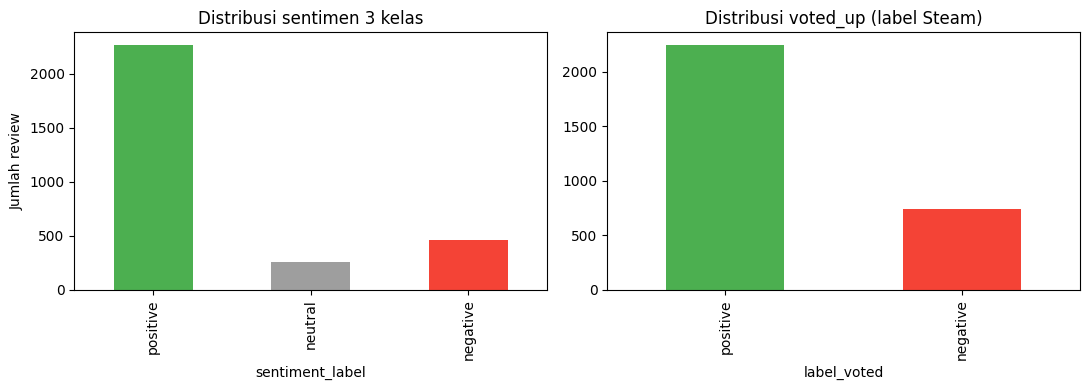

sentiment_label
positive    0.761
negative    0.153
neutral     0.086
Name: proportion, dtype: float64


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Pastikan dataframe tersedia walaupun sel EDA dijalankan langsung
if "df" not in globals():
    output_csv = OUTPUT_CSV if "OUTPUT_CSV" in globals() else "../steamScript/steam_reviews_1449110_clean.csv"
    df = pd.read_csv(output_csv)
    print(f"df dimuat dari: {output_csv}")

# Pastikan kolom yang dipakai EDA ada
if "sentiment_label" not in df.columns:
    if "review_clean" in df.columns:
        POS_TH, NEG_TH = 0.05, -0.05
        sia = SentimentIntensityAnalyzer()
        scores = df["review_clean"].apply(lambda t: sia.polarity_scores(t if isinstance(t, str) else ""))
        df["sentiment_label"] = scores.apply(
            lambda d: "positive" if d["compound"] >= POS_TH else ("negative" if d["compound"] <= NEG_TH else "neutral")
        )
        print("sentiment_label dibuat ulang dari review_clean dengan VADER")
    else:
        raise ValueError("Kolom 'sentiment_label' tidak ada dan 'review_clean' juga tidak tersedia.")

if "label_voted" not in df.columns and "voted_up" in df.columns:
    df["label_voted"] = df["voted_up"].astype(str).str.lower().map({"true": "positive", "false": "negative"})

# Distribusi sentimen vs label voted_up
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
order = ["positive", "neutral", "negative"]
df["sentiment_label"].value_counts().reindex(order, fill_value=0).plot(
    kind="bar", ax=axes[0], color=["#4caf50", "#9e9e9e", "#f44336"])
axes[0].set_title("Distribusi sentimen 3 kelas")
axes[0].set_ylabel("Jumlah review")
df["label_voted"].value_counts().reindex(["positive", "negative"], fill_value=0).plot(
    kind="bar", ax=axes[1], color=["#4caf50", "#f44336"])
axes[1].set_title("Distribusi voted_up (label Steam)")
plt.tight_layout(); plt.show()
print(df["sentiment_label"].value_counts(normalize=True).round(3))

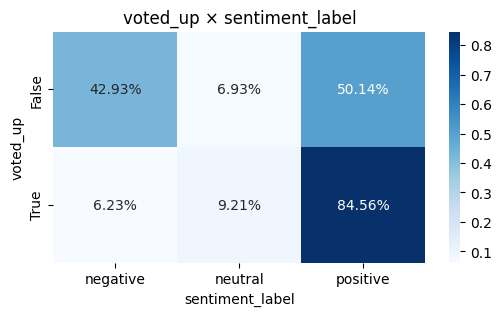

In [6]:
# mismatch antara voted_up dan sentiment_label
ct = pd.crosstab(df["voted_up"], df["sentiment_label"], normalize="index")
plt.figure(figsize=(6,3))
sns.heatmap(ct, annot=True, fmt=".2%", cmap="Blues")
plt.title("voted_up × sentiment_label")
plt.show()

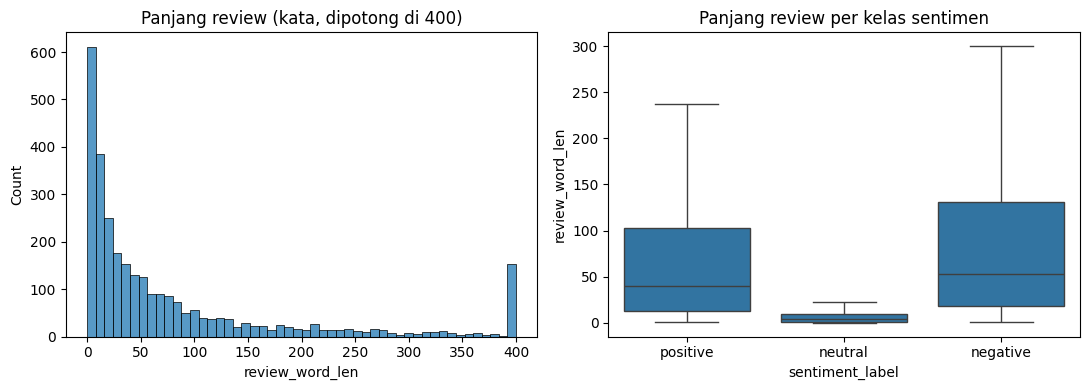

In [7]:
#distribusi panjang review
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(df["review_word_len"].clip(upper=400), bins=50, ax=ax[0])
ax[0].set_title("Panjang review (kata, dipotong di 400)")
sns.boxplot(data=df, x="sentiment_label", y="review_word_len",
            order=order, ax=ax[1], showfliers=False)
ax[1].set_title("Panjang review per kelas sentimen")
plt.tight_layout(); plt.show()

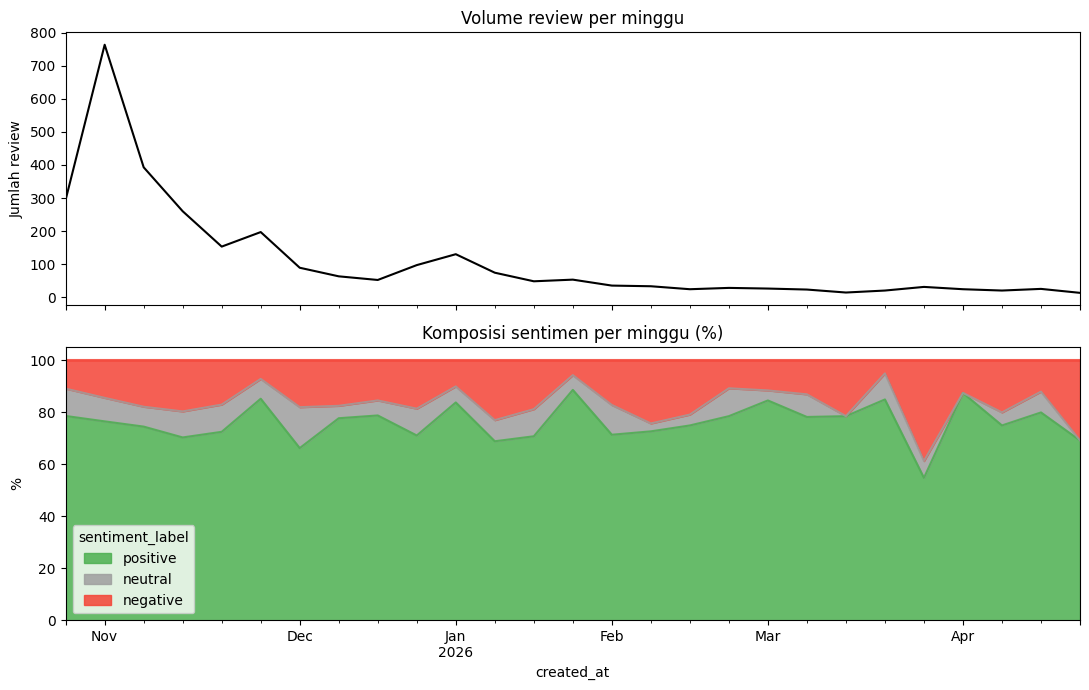

In [9]:
# tren volume dan komposisi sentimen per minggu
import pandas as pd
import matplotlib.pyplot as plt

if "df" not in globals():
    output_csv = OUTPUT_CSV if "OUTPUT_CSV" in globals() else "../steamScript/steam_reviews_1449110_clean.csv"
    df = pd.read_csv(output_csv)
    print(f"df dimuat dari: {output_csv}")

if "sentiment_label" not in df.columns:
    raise ValueError("Kolom 'sentiment_label' tidak ditemukan. Jalankan sel labelling terlebih dahulu.")

# Pastikan created_at bertipe datetime agar bisa dipakai pd.Grouper(freq='W')
df["created_at"] = pd.to_datetime(df.get("created_at"), errors="coerce")
tmp = df.dropna(subset=["created_at", "sentiment_label"]).copy()

if "order" not in globals():
    order = ["positive", "neutral", "negative"]

weekly = (tmp.set_index("created_at")
            .groupby([pd.Grouper(freq="W"), "sentiment_label"])
            .size().unstack(fill_value=0))
weekly = weekly.reindex(columns=order, fill_value=0)

fig, ax = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
weekly.sum(axis=1).plot(ax=ax[0], color="black")
ax[0].set_title("Volume review per minggu")
ax[0].set_ylabel("Jumlah review")

weekly_pct = (weekly.div(weekly.sum(axis=1).replace(0, pd.NA), axis=0) * 100).fillna(0)
weekly_pct.plot.area(
    ax=ax[1], color=["#4caf50", "#9e9e9e", "#f44336"], alpha=0.85)
ax[1].set_title("Komposisi sentimen per minggu (%)")
ax[1].set_ylabel("%")
plt.tight_layout(); plt.show()

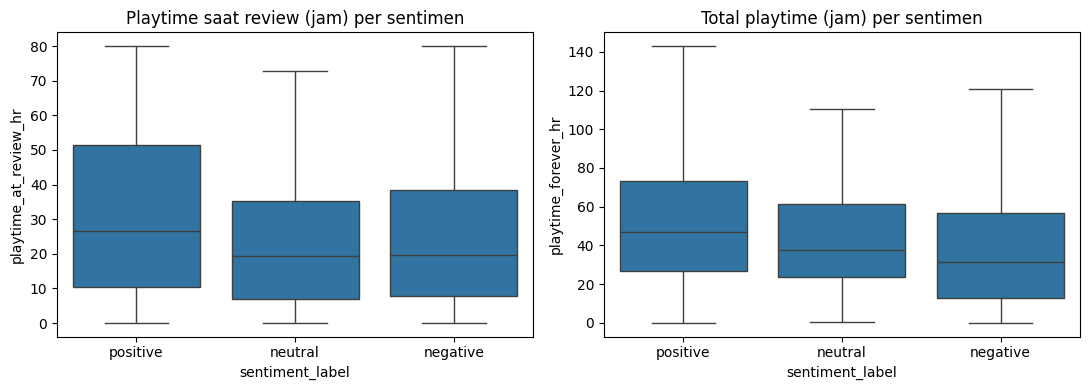

In [10]:
# playtime vs sentimen
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(data=df, x="sentiment_label", order=order,
            y=df["playtime_at_review_hr"].clip(upper=80),
            ax=ax[0], showfliers=False)
ax[0].set_title("Playtime saat review (jam) per sentimen")
sns.boxplot(data=df, x="sentiment_label", order=order,
            y=df["playtime_forever_hr"].clip(upper=300),
            ax=ax[1], showfliers=False)
ax[1].set_title("Total playtime (jam) per sentimen")
plt.tight_layout(); plt.show()

Persentase review diedit: 0.173


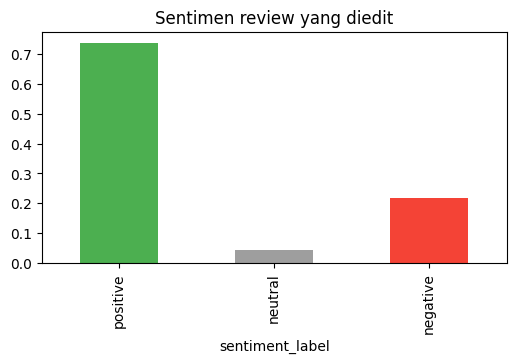

In [11]:
#review yang diedit
print("Persentase review diedit:", df["was_edited"].mean().round(3))
edited = df[df["was_edited"]]
edited["sentiment_label"].value_counts(normalize=True).reindex(order).plot(
    kind="bar", figsize=(6,3), color=["#4caf50", "#9e9e9e", "#f44336"])
plt.title("Sentimen review yang diedit")
plt.show()

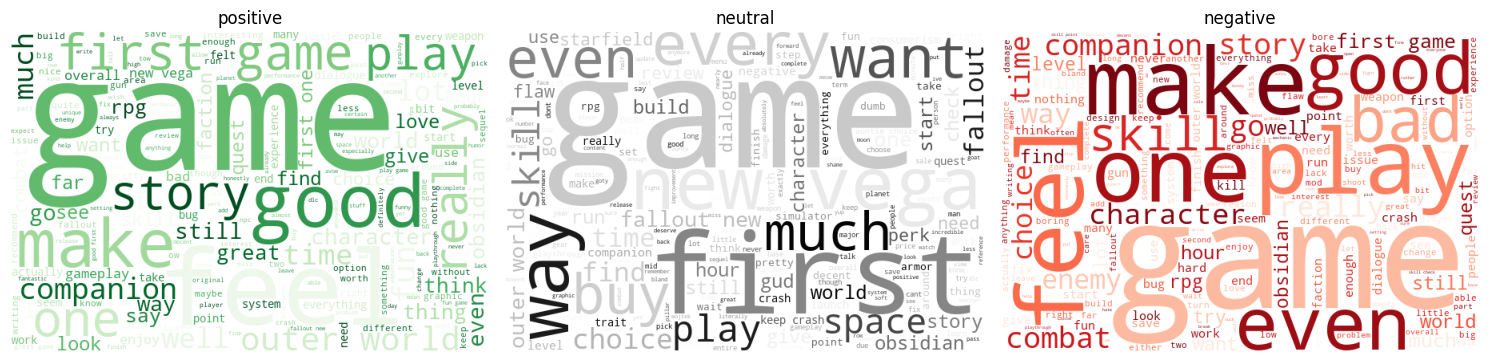


Top 20 kata - positive
      term  count
0     game   4762
1      but   2197
2     like   1796
3    first   1620
4      not   1402
5     good   1348
6     more   1183
7      one   1097
8     play   1065
9    world   1039
10    feel    996
11     get    885
12  really    834
13    make    806
14   story    762
15     fun    761
16   great    681
17    well    668
18    time    654
19    much    628

Top 20 kata - neutral
       term  count
0      game     73
1     first     30
2       but     25
3       not     22
4   fallout     18
5       new     15
6      vega     15
7     world     15
8       way     14
9    choice     14
10    every     13
11      get     12
12     want     12
13     even     11
14      buy     11
15     much     11
16     play     11
17    skill     11
18    space     10
19    outer     10

Top 20 kata - negative
      term  count
0     game   1033
1      but    496
2      not    422
3     like    300
4      get    271
5    first    261
6       no    250
7      o

In [12]:
import ast
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

if "df" not in globals():
    output_csv = OUTPUT_CSV if "OUTPUT_CSV" in globals() else "../steamScript/steam_reviews_1449110_clean.csv"
    df = pd.read_csv(output_csv)
    print(f"df dimuat dari: {output_csv}")

if "sentiment_label" not in df.columns:
    raise ValueError("Kolom 'sentiment_label' tidak ditemukan. Jalankan sel labelling terlebih dahulu.")

if "review_tokens" not in df.columns:
    raise ValueError("Kolom 'review_tokens' tidak ditemukan. Jalankan preprocessing terlebih dahulu.")

# Jika review_tokens terbaca sebagai string list dari CSV, ubah kembali ke list
def _to_tokens(x):
    if isinstance(x, list):
        return [str(t) for t in x]
    if isinstance(x, str):
        x = x.strip()
        if x.startswith("[") and x.endswith("]"):
            try:
                parsed = ast.literal_eval(x)
                if isinstance(parsed, list):
                    return [str(t) for t in parsed]
            except Exception:
                pass
        return [tok for tok in x.split() if tok]
    return []

token_series = df["review_tokens"].apply(_to_tokens)

if "order" not in globals():
    order = ["positive", "neutral", "negative"]

def top_words(label, n=20):
    toks = token_series[df["sentiment_label"] == label]
    return Counter([t for lst in toks for t in lst]).most_common(n)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
palette = {"positive": "Greens", "neutral": "Greys", "negative": "Reds"}
for ax, cls in zip(axes, order):
    text = " ".join(t for lst in token_series[df["sentiment_label"] == cls] for t in lst)
    wc = WordCloud(width=600, height=400, background_color="white",
                   colormap=palette[cls]).generate(text or "empty")
    ax.imshow(wc)
    ax.axis("off")
    ax.set_title(cls)
plt.tight_layout()
plt.show()

for cls in order:
    print(f"\nTop 20 kata - {cls}")
    print(pd.DataFrame(top_words(cls), columns=["term", "count"]))

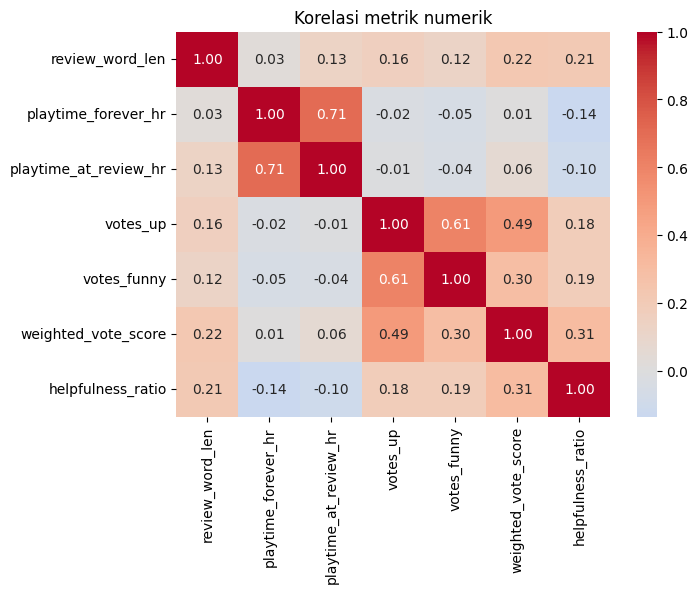

In [13]:
#korelasi metrik numerik
num_cols = ["review_word_len", "playtime_forever_hr",
            "playtime_at_review_hr", "votes_up", "votes_funny",
            "weighted_vote_score", "helpfulness_ratio"]
plt.figure(figsize=(7,5))
sns.heatmap(df[num_cols].corr(numeric_only=True), annot=True, fmt=".2f",
            cmap="coolwarm", center=0)
plt.title("Korelasi metrik numerik"); plt.show()

## **Split Data**

Tahap ini memisahkan data menjadi data latih dan data uji agar evaluasi model tetap adil.

Semua teknik augmentasi hanya akan diterapkan ke data latih setelah proses split selesai. Dengan begitu, data uji tetap bersih dan tidak tercampur oleh sampel sintetis dari kelas lain.

Tahap split data memisahkan data menjadi data latih dan data uji.

Pembagian dilakukan secara stratified supaya proporsi kelas tetap seimbang di train dan test. Ini penting agar evaluasi model tidak bias karena salah satu kelas terlalu dominan di salah satu subset.

Setelah split selesai, notebook melakukan augmentasi hanya pada data latih.

Pendekatan ini penting supaya model melihat variasi bahasa yang lebih kaya tanpa membuat data uji tercampur. Karena distribusi kelas cukup timpang, augmentasi dipakai untuk menaikkan jumlah sampel kelas minor sampai mendekati kelas mayor.

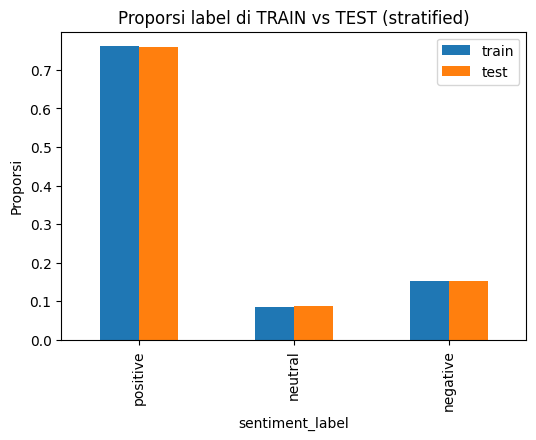

In [ ]:
RANDOM_STATE = 42
df = df.dropna(subset=["sentiment_label", "review_clean"])
df = df[df["review_clean"].str.strip().str.len() > 0].reset_index(drop=True)
X = df["review_clean"]
y = df["sentiment_label"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE,
 )

# Visualisasi proporsi label train vs test
prop_df = pd.DataFrame({
    "train": y_train.value_counts(normalize=True),
    "test":  y_test.value_counts(normalize=True),
}).reindex(order)
prop_df.plot(kind="bar", figsize=(6,4))
plt.title("Proporsi label di TRAIN vs TEST (stratified)")
plt.ylabel("Proporsi"); plt.show()

In [32]:
# Advanced class-aware augmentation hanya untuk data latih
import pandas as pd
import random
import numpy as np
from nltk.corpus import wordnet as wn, stopwords
from nltk.tokenize import word_tokenize
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

if "RANDOM_STATE" not in globals():
    RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# Fallback jika EN_STOPWORDS belum didefinisikan oleh cell lain
if "EN_STOPWORDS" in globals():
    base_stopwords = set(EN_STOPWORDS)
else:
    try:
        base_stopwords = set(stopwords.words("english"))
    except Exception:
        base_stopwords = {"the", "a", "an", "and", "or", "to", "of", "in", "on", "for", "with", "is", "are", "was", "were", "be"}

sentiment_lexicon = set(SentimentIntensityAnalyzer().lexicon.keys())
protected_words = base_stopwords | sentiment_lexicon | {"n't", "not", "no", "never", "but", "however", "though"}

def _synonyms(word: str) -> list[str]:
    candidates = set()
    for syn in wn.synsets(word):
        for lemma in syn.lemmas():
            candidate = lemma.name().replace("_", " ").lower()
            if candidate != word and candidate.isalpha() and candidate not in protected_words:
                candidates.add(candidate)
    return sorted(candidates)

def synonym_replacement(tokens: list[str], n: int = 1) -> list[str]:
    tokens = tokens.copy()
    eligible = [i for i, tok in enumerate(tokens) if tok.isalpha() and tok not in protected_words and len(tok) > 2]
    random.shuffle(eligible)
    replaced = 0
    for idx in eligible:
        synonyms = _synonyms(tokens[idx])
        if synonyms:
            tokens[idx] = random.choice(synonyms)
            replaced += 1
        if replaced >= n:
            break
    return tokens

def random_swap(tokens: list[str], n: int = 1) -> list[str]:
    tokens = tokens.copy()
    if len(tokens) < 2:
        return tokens
    for _ in range(n):
        i, j = random.sample(range(len(tokens)), 2)
        tokens[i], tokens[j] = tokens[j], tokens[i]
    return tokens

def random_deletion(tokens: list[str], p: float = 0.12) -> list[str]:
    if len(tokens) <= 2:
        return tokens
    kept = [tok for tok in tokens if tok in protected_words or random.random() > p]
    return kept if kept else tokens

def augment_text(text: str) -> str:
    if not isinstance(text, str) or not text.strip():
        return ""
    tokens = word_tokenize(text.lower())
    tokens = [tok for tok in tokens if tok.strip()]
    if len(tokens) < 3:
        return text
    op = random.choices(
        population=["synonym", "swap", "delete", "combo"],
        weights=[0.35, 0.20, 0.20, 0.25],
        k=1
    )[0]
    if op == "synonym":
        tokens = synonym_replacement(tokens, n=max(1, len(tokens) // 10))
    elif op == "swap":
        tokens = random_swap(tokens, n=1)
    elif op == "delete":
        tokens = random_deletion(tokens, p=0.10)
    else:
        tokens = synonym_replacement(tokens, n=max(1, len(tokens) // 12))
        tokens = random_swap(tokens, n=1)
    return " ".join(tokens)

train_df = pd.DataFrame({"text": X_train.values, "label": y_train.values})
class_counts = train_df["label"].value_counts()
target_count = int(class_counts.max())

augmented_frames = []
for label, group in train_df.groupby("label"):
    base_texts = group["text"].tolist()
    generated = base_texts.copy()
    while len(generated) < target_count:
        source_text = random.choice(base_texts)
        generated.append(augment_text(source_text))
    augmented_frames.append(pd.DataFrame({"text": generated[:target_count], "label": [label] * target_count}))

train_balanced_df = pd.concat(augmented_frames, ignore_index=True)
train_balanced_df = train_balanced_df.sample(frac=1.0, random_state=RANDOM_STATE).reset_index(drop=True)

X_train_aug = train_balanced_df["text"]
y_train_aug = train_balanced_df["label"]

# Pakai versi augmented untuk modelling selanjutnya
X_train = X_train_aug
y_train = y_train_aug

print("Distribusi label sebelum augmentasi:")
print(class_counts)
print("\nDistribusi label sesudah augmentasi:")
print(y_train_aug.value_counts())
print(f"\nUkuran train sebelum: {len(train_df)}")
print(f"Ukuran train sesudah : {len(train_balanced_df)}")

Distribusi label sebelum augmentasi:
label
positive    1816
neutral     1816
negative    1816
Name: count, dtype: int64

Distribusi label sesudah augmentasi:
label
positive    1816
neutral     1816
negative    1816
Name: count, dtype: int64

Ukuran train sebelum: 5448
Ukuran train sesudah : 5448


## **Modelling**

Pada tahap modelling, notebook membangun beberapa pipeline klasifikasi yang membandingkan TF-IDF dengan beberapa algoritma linear.

Di titik ini proses encoding teks terjadi. Kalimat yang awalnya berbentuk string diubah menjadi vektor numerik menggunakan TF-IDF. Setiap kolom fitur merepresentasikan kata atau n-gram, sedangkan nilainya menunjukkan seberapa penting kata tersebut di dalam satu review dan di seluruh korpus.

Alurnya adalah sebagai berikut: teks bersih masuk ke TF-IDF, hasil encoding menjadi matriks sparse, lalu model linear belajar memisahkan kelas positif, netral, dan negatif berdasarkan bobot tiap fitur. Karena input sudah berupa vektor numerik, model seperti Logistic Regression, Linear SVC, dan Naive Bayes bisa dipakai secara efisien.

Tujuan tahap ini adalah mencari baseline yang kuat dan stabil untuk data sentimen tiga kelas. Karena teks sudah cukup bersih, model linear biasanya menjadi kandidat yang masuk akal untuk performa dan interpretabilitas.

In [33]:
def make_pipeline(classifier, use_smote=False):
    steps = [("tfidf", TfidfVectorizer(
        ngram_range=(1, 2), min_df=3, max_df=0.95, sublinear_tf=True))]
    if use_smote:
        steps.append(("smote", SMOTE(random_state=RANDOM_STATE)))
    steps.append(("clf", classifier))
    return ImbPipeline(steps)
pipelines = {
    "logreg_balanced": make_pipeline(
        LogisticRegression(max_iter=2000, class_weight="balanced",
                           random_state=RANDOM_STATE)),
    "linsvc_balanced": make_pipeline(
        LinearSVC(class_weight="balanced", random_state=RANDOM_STATE)),
    "nb_smote": make_pipeline(MultinomialNB(), use_smote=True),
}

             model  f1_macro_mean  f1_macro_std  bal_acc_mean  \
1  linsvc_balanced       0.960222      0.004722      0.960536   
0  logreg_balanced       0.940720      0.008429      0.941259   
2         nb_smote       0.835549      0.012688      0.836283   

   roc_auc_ovr_mean  
1               NaN  
0          0.988418  
2          0.977364  


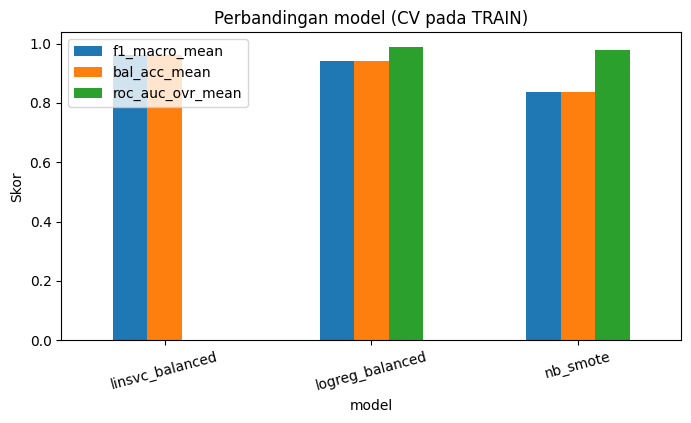

In [34]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

base_scoring = {
    "f1_macro": "f1_macro",
    "balanced_accuracy": "balanced_accuracy",
}

cv_rows = []
for name, pipe in pipelines.items():
    clf = pipe.named_steps["clf"]
    scoring = dict(base_scoring)

    # ROC-AUC multiclass hanya dipakai jika classifier punya predict_proba
    use_roc_auc = hasattr(clf, "predict_proba")
    if use_roc_auc:
        scoring["roc_auc_ovr"] = "roc_auc_ovr_weighted"

    res = cross_validate(
        pipe, X_train, y_train,
        cv=cv, scoring=scoring, n_jobs=-1
    )

    row = {
        "model": name,
        "f1_macro_mean": np.nanmean(res["test_f1_macro"]),
        "f1_macro_std": np.nanstd(res["test_f1_macro"]),
        "bal_acc_mean": np.nanmean(res["test_balanced_accuracy"]),
        "roc_auc_ovr_mean": np.nan,
    }
    if use_roc_auc:
        row["roc_auc_ovr_mean"] = np.nanmean(res["test_roc_auc_ovr"])

    cv_rows.append(row)

cv_df = pd.DataFrame(cv_rows).sort_values("f1_macro_mean", ascending=False)
print(cv_df)

# Visualisasi perbandingan
cv_df.set_index("model")[["f1_macro_mean", "bal_acc_mean", "roc_auc_ovr_mean"]].plot(
    kind="bar", figsize=(8, 4)
 )
plt.title("Perbandingan model (CV pada TRAIN)")
plt.ylabel("Skor")
plt.xticks(rotation=15)
plt.show()

In [37]:
# Tuning model terbaik
best_name = cv_df.iloc[0]["model"]
print("Tuning:", best_name)
best_pipe = pipelines[best_name]
clf_base = best_pipe.named_steps["clf"]

# Param grid harus sesuai jenis classifier agar tidak error parameter invalid
base_tfidf_grid = {
    "tfidf__ngram_range": [(1, 1), (1, 2), (1, 3)],
    "tfidf__min_df": [2, 3, 5],
    "tfidf__max_features": [20000, 50000, None],
}

if isinstance(clf_base, LogisticRegression):
    param_grid = {
        **base_tfidf_grid,
        "clf__C": [0.25, 0.5, 1.0, 2.0, 4.0],
        "clf__solver": ["lbfgs", "newton-cg", "saga"],
    }
elif isinstance(clf_base, LinearSVC):
    param_grid = {
        **base_tfidf_grid,
        "clf__C": [0.25, 0.5, 1.0, 2.0, 4.0],
        "clf__loss": ["hinge", "squared_hinge"],
        "clf__max_iter": [3000, 5000],
    }
elif isinstance(clf_base, MultinomialNB):
    param_grid = {
        **base_tfidf_grid,
        "clf__alpha": [0.1, 0.5, 1.0, 2.0],
    }
else:
    raise ValueError(f"Classifier untuk tuning belum didukung otomatis: {type(clf_base)}")

grid = GridSearchCV(
    best_pipe,
    param_grid=param_grid,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
    refit=True,
    verbose=1,
    error_score="raise",
 )
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV f1 :", grid.best_score_)
best_model = grid.best_estimator_

Tuning: linsvc_balanced
Fitting 5 folds for each of 540 candidates, totalling 2700 fits
Best params: {'clf__C': 2.0, 'clf__loss': 'hinge', 'clf__max_iter': 3000, 'tfidf__max_features': None, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 3)}
Best CV f1 : 0.9685397430163416


Setelah model terbaik ditemukan dari cross-validation, notebook melakukan tuning parameter yang lebih detail.

Grid search mencoba kombinasi n-gram, min_df, max_features, dan parameter classifier agar mendapatkan konfigurasi yang memberi skor F1 macro terbaik pada data latih.

              precision    recall  f1-score   support

    negative     0.9474    0.1978    0.3273        91
     neutral     0.7321    0.7885    0.7593        52
    positive     0.8525    0.9802    0.9119       454

    accuracy                         0.8442       597
   macro avg     0.8440    0.6555    0.6661       597
weighted avg     0.8565    0.8442    0.8095       597

Balanced accuracy: 0.6554799825724936
F1 macro         : 0.6661390774778754
ROC-AUC OvR weighted: 0.8757357297214542


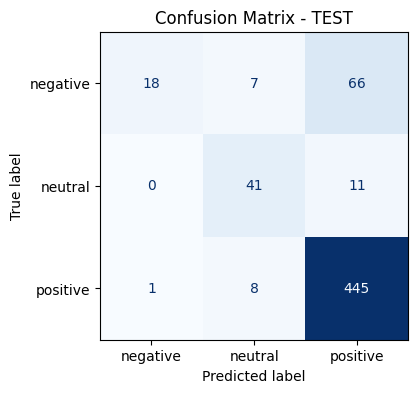

In [38]:
y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred, digits=4))
print("Balanced accuracy:", balanced_accuracy_score(y_test, y_pred))
print("F1 macro         :", f1_score(y_test, y_pred, average="macro"))
classes = best_model.classes_
try:
    if hasattr(best_model.named_steps["clf"], "predict_proba"):
        y_score = best_model.predict_proba(X_test)
    else:
        y_score = best_model.decision_function(X_test)
    y_test_bin = label_binarize(y_test, classes=classes)
    print("ROC-AUC OvR weighted:",
          roc_auc_score(y_test_bin, y_score, average="weighted",
                        multi_class="ovr"))
except Exception as e:
    print("ROC-AUC skip:", e)
fig, ax = plt.subplots(figsize=(5,4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, labels=classes, cmap="Blues",
    colorbar=False, ax=ax)
plt.title("Confusion Matrix - TEST"); plt.show()

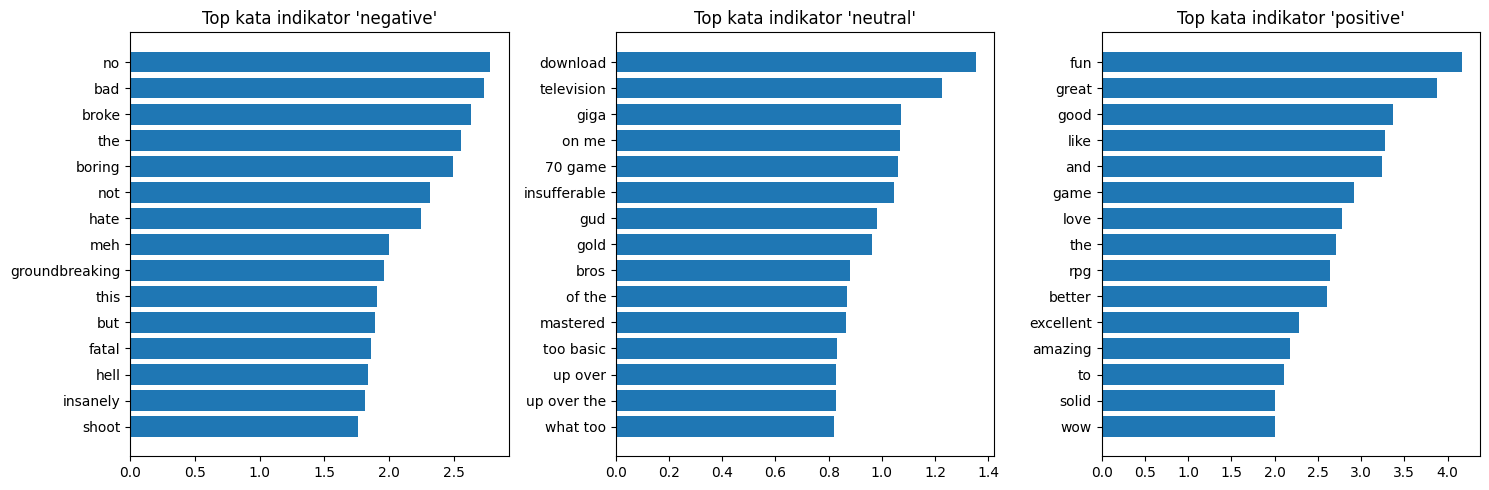

Model disimpan: sentiment_model_3class.joblib


array(['positive', 'neutral', 'neutral'], dtype=object)

In [40]:
import joblib
import numpy as np
import matplotlib.pyplot as plt

clf = best_model.named_steps["clf"]
vect = best_model.named_steps["tfidf"]
if hasattr(clf, "coef_"):
    feature_names = np.array(vect.get_feature_names_out())
    fig, axes = plt.subplots(1, len(clf.classes_), figsize=(5 * len(clf.classes_), 5))
    if len(clf.classes_) == 1:
        axes = [axes]
    for i, cls in enumerate(clf.classes_):
        top_idx = np.argsort(clf.coef_[i])[-15:]
        axes[i].barh(feature_names[top_idx], clf.coef_[i][top_idx])
        axes[i].set_title(f"Top kata indikator '{cls}'")
    plt.tight_layout()
    plt.show()

joblib.dump(best_model, "sentiment_model_3class.joblib")
print("Model disimpan: sentiment_model_3class.joblib")

# Pakai untuk review baru
loaded = joblib.load("sentiment_model_3class.joblib")
loaded.predict([
    "Best game I've played this year, so much fun!",
    "Crashes every 5 minutes, don't waste your money",
    "It's okay, nothing special.",
])